In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [25]:
# load data
fname_train_cont = "../test/embeddings_contrastive.train.npz"
fname_test_cont = "../test/embeddings_contrastive.test.npz"
data_cont = {
    "train": np.load(fname_train_cont, allow_pickle=True),
    "test": np.load(fname_test_cont, allow_pickle=True)
}

fname_train_found = "../test/embeddings_foundation.train.npz"
fname_test_found = "../test/embeddings_foundation.test.npz"
data_found = {
    "train": np.load(fname_train_found, allow_pickle=True),
    "test": np.load(fname_test_found, allow_pickle=True)
}

fname_train_fine = "../test/embeddings_finetuned.train.npz"
fname_test_fine = "../test/embeddings_finetuned.test.npz"
data_fine = {
    "train": np.load(fname_train_fine, allow_pickle=True),
    "test": np.load(fname_test_fine, allow_pickle=True)
}

fname_train_sup = "../test/embeddings_supervised.train.npz"
fname_test_sup = "../test/embeddings_supervised.test.npz"
data_sup = {
    "train": np.load(fname_train_sup, allow_pickle=True),
    "test": np.load(fname_test_sup, allow_pickle=True)
}

In [26]:
tsne = TSNE(n_components=2, random_state=42)
pca = PCA(n_components=2)

print("Processing contrastive embeddings...")
data_cont_tsne = {
    "train": tsne.fit_transform(data_cont['train']['embeddings']),
    "test": tsne.fit_transform(data_cont['test']['embeddings']),
}

print("Processing foundation embeddings...")
data_found_tsne = {
    "train": tsne.fit_transform(data_found['train']['embeddings']),
    "test": tsne.fit_transform(data_found['test']['embeddings']),
}

print("Processing finetuned embeddings...")
data_fine_tsne = {
    "train": tsne.fit_transform(data_fine['train']['embeddings']),
    "test": tsne.fit_transform(data_fine['test']['embeddings']),
}

print("Processing supervised embeddings...")
data_sup_tsne = {
    "train": tsne.fit_transform(data_sup['train']['embeddings']),
    "test": tsne.fit_transform(data_sup['test']['embeddings']),
}

print("Processing PCAs...")
data_cont_pca = {
    "train": pca.fit_transform(data_cont['train']['embeddings']),
    "test": pca.transform(data_cont['test']['embeddings']),
}

data_found_pca = {
    "train": pca.fit_transform(data_found['train']['embeddings']),
    "test": pca.transform(data_found['test']['embeddings']),
}

data_fine_pca = {
    "train": pca.fit_transform(data_fine['train']['embeddings']),
    "test": pca.transform(data_fine['test']['embeddings']),
}

data_sup_pca = {
    "train": pca.fit_transform(data_sup['train']['embeddings']),
    "test": pca.transform(data_sup['test']['embeddings']),
}

Processing contrastive embeddings...
Processing foundation embeddings...
Processing finetuned embeddings...
Processing supervised embeddings...
Processing PCAs...


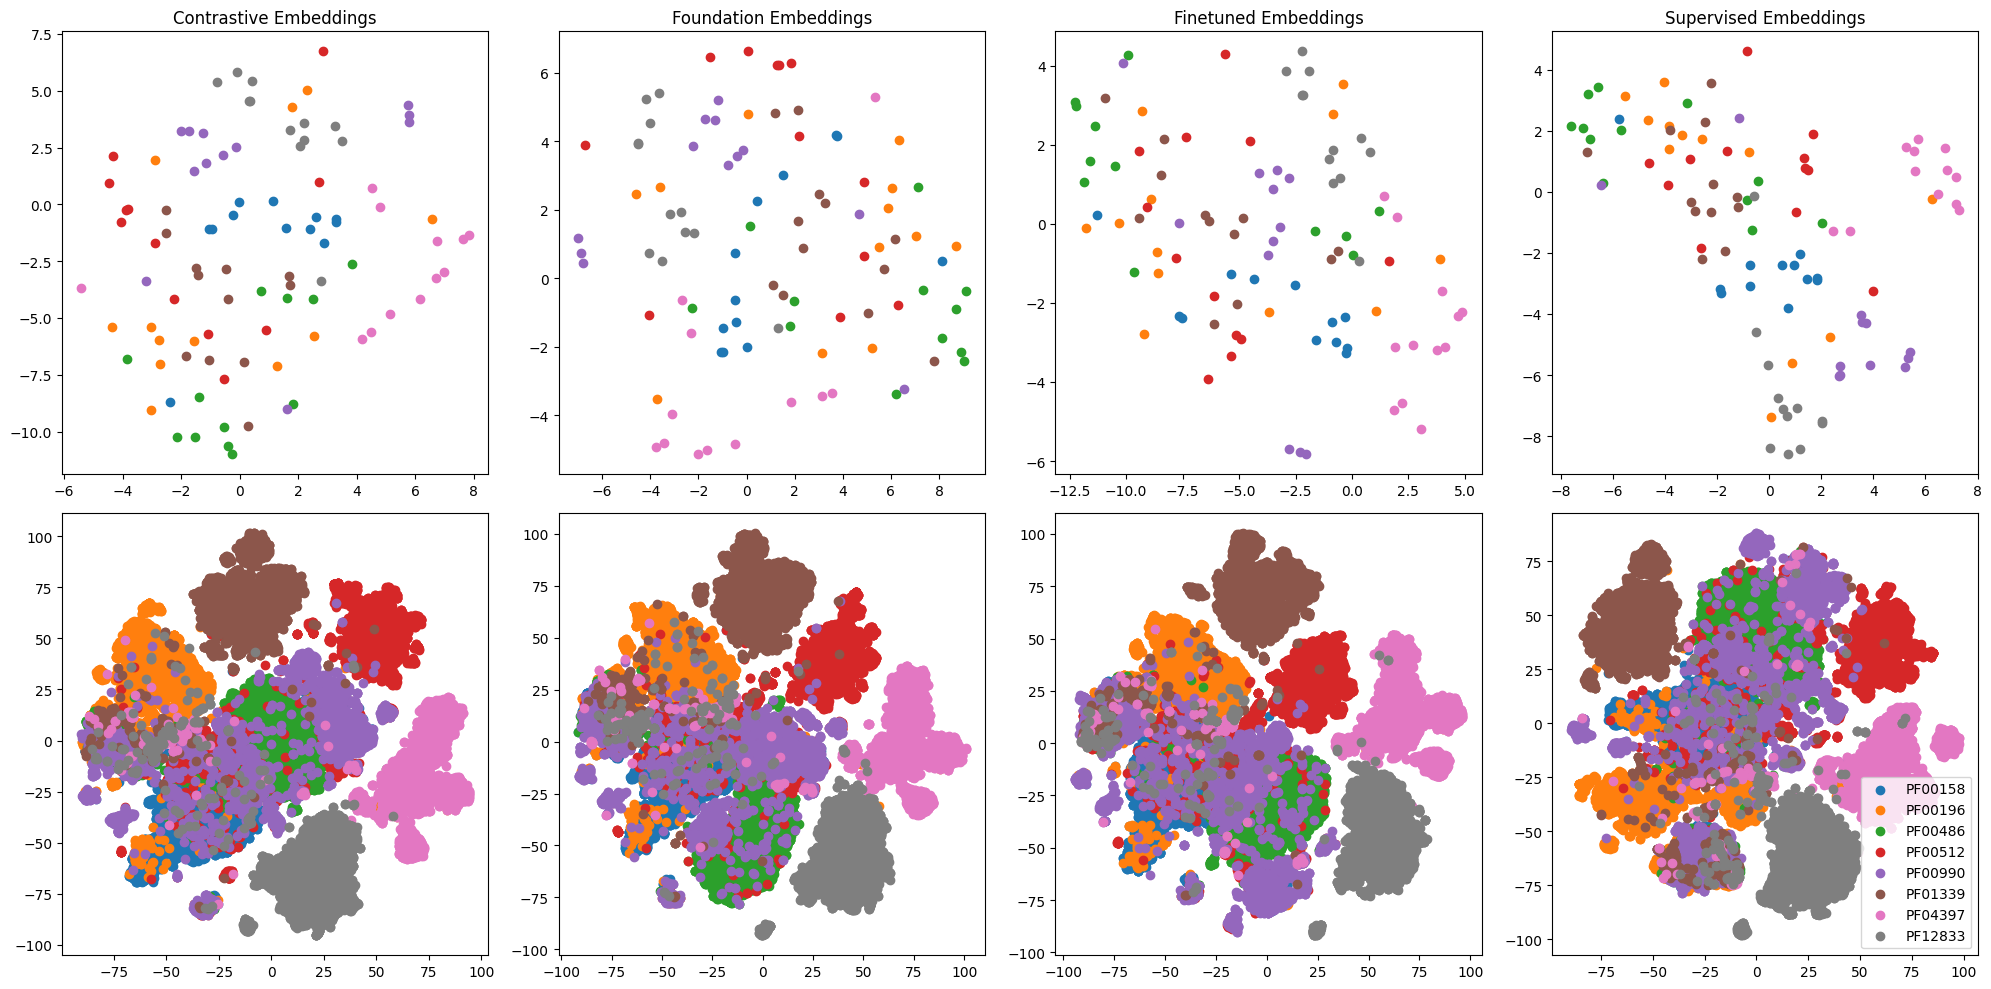

In [27]:
unique_labels = np.unique(data_cont["train"]["labels"])

fig, ax = plt.subplots(2, 4, figsize=(20, 10), dpi=100)
list_train_labels = [data_cont["train"]["labels"], data_found["train"]["labels"], data_fine["train"]["labels"], data_sup["train"]["labels"]]
list_test_labels = [data_cont["test"]["labels"], data_found["test"]["labels"], data_fine["test"]["labels"], data_sup["test"]["labels"]]
for i, data in enumerate([data_cont_tsne, data_found_tsne, data_fine_tsne, data_sup_tsne]):
    ax[0, i].set_title(f"{['Contrastive', 'Foundation', 'Finetuned', 'Supervised'][i]} Embeddings")
    for l in unique_labels:
        ids1 = np.where(list_train_labels[i] == l)
        ids2 = np.where(list_test_labels[i] == l)
        ax[0, i].scatter(data["train"][ids1, 0], data["train"][ids1, 1], label=l)
        ax[1, i].scatter(data["test"][ids2, 0], data["test"][ids2, 1], label=l)

plt.legend()
plt.tight_layout()
plt.show()

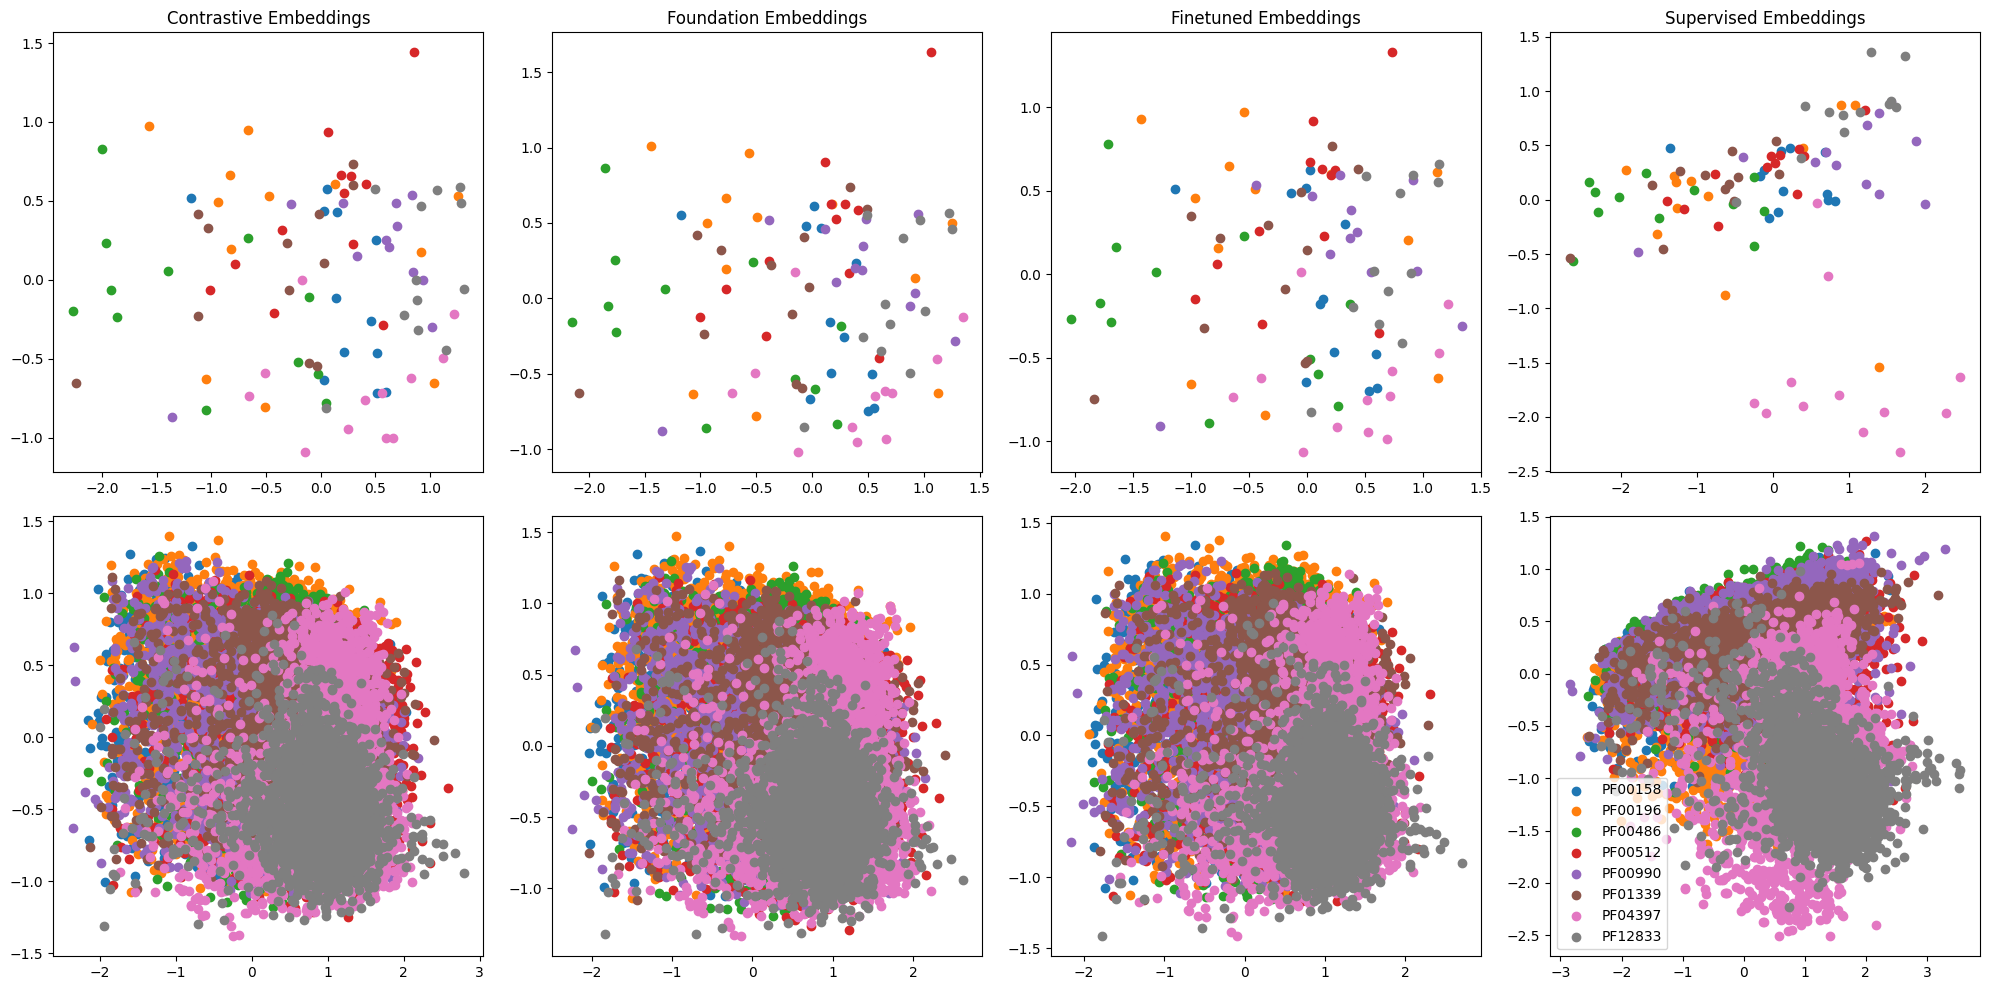

In [28]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10), dpi=100)
list_train_labels = [data_cont["train"]["labels"], data_found["train"]["labels"], data_fine["train"]["labels"], data_sup["train"]["labels"]]
list_test_labels = [data_cont["test"]["labels"], data_found["test"]["labels"], data_fine["test"]["labels"], data_sup["test"]["labels"]]
for i, data in enumerate([data_cont_pca, data_found_pca, data_fine_pca, data_sup_pca]):
    ax[0, i].set_title(f"{['Contrastive', 'Foundation', 'Finetuned', 'Supervised'][i]} Embeddings")
    for l in unique_labels:
        ids1 = np.where(list_train_labels[i] == l)
        ids2 = np.where(list_test_labels[i] == l)
        ax[0, i].scatter(data["train"][ids1, 0], data["train"][ids1, 1], label=l)
        ax[1, i].scatter(data["test"][ids2, 0], data["test"][ids2, 1], label=l)

plt.legend()
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

embedding_sets = {
    "contrastive": data_cont,
    "foundation": data_found,
    "finetuned": data_fine,
    "supervised": data_sup
}

results = {}

for name, ds in embedding_sets.items():
    X_train = ds["train"]["embeddings"]
    y_train = ds["train"]["labels"]
    X_test = ds["test"]["embeddings"]
    y_test = ds["test"]["labels"]

    clf = LogisticRegression(max_iter=2000, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "roc_auc_ovr_macro": roc_auc_score(
            y_test, y_proba, multi_class="ovr", average="macro", labels=clf.classes_
        ),
    }

for name, metrics in results.items():
    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


contrastive
  accuracy: 0.2977
  f1_macro: 0.2801
  f1_weighted: 0.2801
  roc_auc_ovr_macro: 0.7027

foundation
  accuracy: 0.2894
  f1_macro: 0.2813
  f1_weighted: 0.2813
  roc_auc_ovr_macro: 0.6913

finetuned
  accuracy: 0.2693
  f1_macro: 0.2684
  f1_weighted: 0.2684
  roc_auc_ovr_macro: 0.6855

supervised
  accuracy: 0.3069
  f1_macro: 0.2810
  f1_weighted: 0.2810
  roc_auc_ovr_macro: 0.6943
